# 03 - Структурный сдвиг 2022 и Feature Engineering

**Цель:** Статистически подтвердить структурный сдвиг в данных (февраль 2022),
проанализировать стабильность связей и создать дополнительные признаки для модели.

**Вход:** `data/panel.csv`  
**Выход:** `data/panel_engineered.csv` с новыми признаками  
**Графики:** `notebooks/figures/03_*.png`

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy import stats
import statsmodels.api as sm
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# --- paths ---
ROOT = Path("../..").resolve()
DATA_DIR = ROOT / 'data'
FIG_DIR  = ROOT / 'notebooks' / 'figures'
FIG_DIR.mkdir(parents=True, exist_ok=True)

# --- style ---
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'figure.dpi': 150,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
    'font.size': 11,
    'legend.fontsize': 10,
    'savefig.bbox': 'tight',
    'savefig.dpi': 150,
})
sns.set_style('whitegrid')

REGIME_COLORS = {'A (до 2022)': '#2196F3', 'B (шок)': '#F44336', 'C (новая норма)': '#4CAF50'}

print('Setup OK')

Setup OK


---
## 2. Загрузка данных и определение режимов

In [2]:
panel = pd.read_csv(DATA_DIR / 'panel.csv', parse_dates=['date'])
print(f'Загружено: {panel.shape[0]:,} строк, {panel.shape[1]} столбцов')
print(f'Период: {panel["date"].min().date()} -- {panel["date"].max().date()}')
print(f'Уникальных ISIN: {panel["isin"].nunique()}')

Загружено: 295,569 строк, 34 столбцов
Период: 2020-01-03 -- 2026-03-30
Уникальных ISIN: 967


In [3]:
# --- Определение режимов ---
REGIME_A_START = pd.Timestamp('2020-01-03')
REGIME_A_END   = pd.Timestamp('2022-02-23')
REGIME_B_START = pd.Timestamp('2022-02-24')
REGIME_B_END   = pd.Timestamp('2022-12-31')
REGIME_C_START = pd.Timestamp('2023-01-01')
REGIME_C_END   = pd.Timestamp('2026-03-30')

def assign_regime(d):
    if d <= REGIME_A_END:
        return 'A (до 2022)'
    elif d <= REGIME_B_END:
        return 'B (шок)'
    else:
        return 'C (новая норма)'

panel['regime'] = panel['date'].apply(assign_regime)

regime_counts = panel['regime'].value_counts().sort_index()
print('Наблюдений по режимам:')
for r, c in regime_counts.items():
    print(f'  {r}: {c:>8,}')

Наблюдений по режимам:
  A (до 2022):   45,542
  B (шок):   20,010
  C (новая норма):  230,017


---
## Part A: Структурный сдвиг 2022

### 3. Сравнение распределений

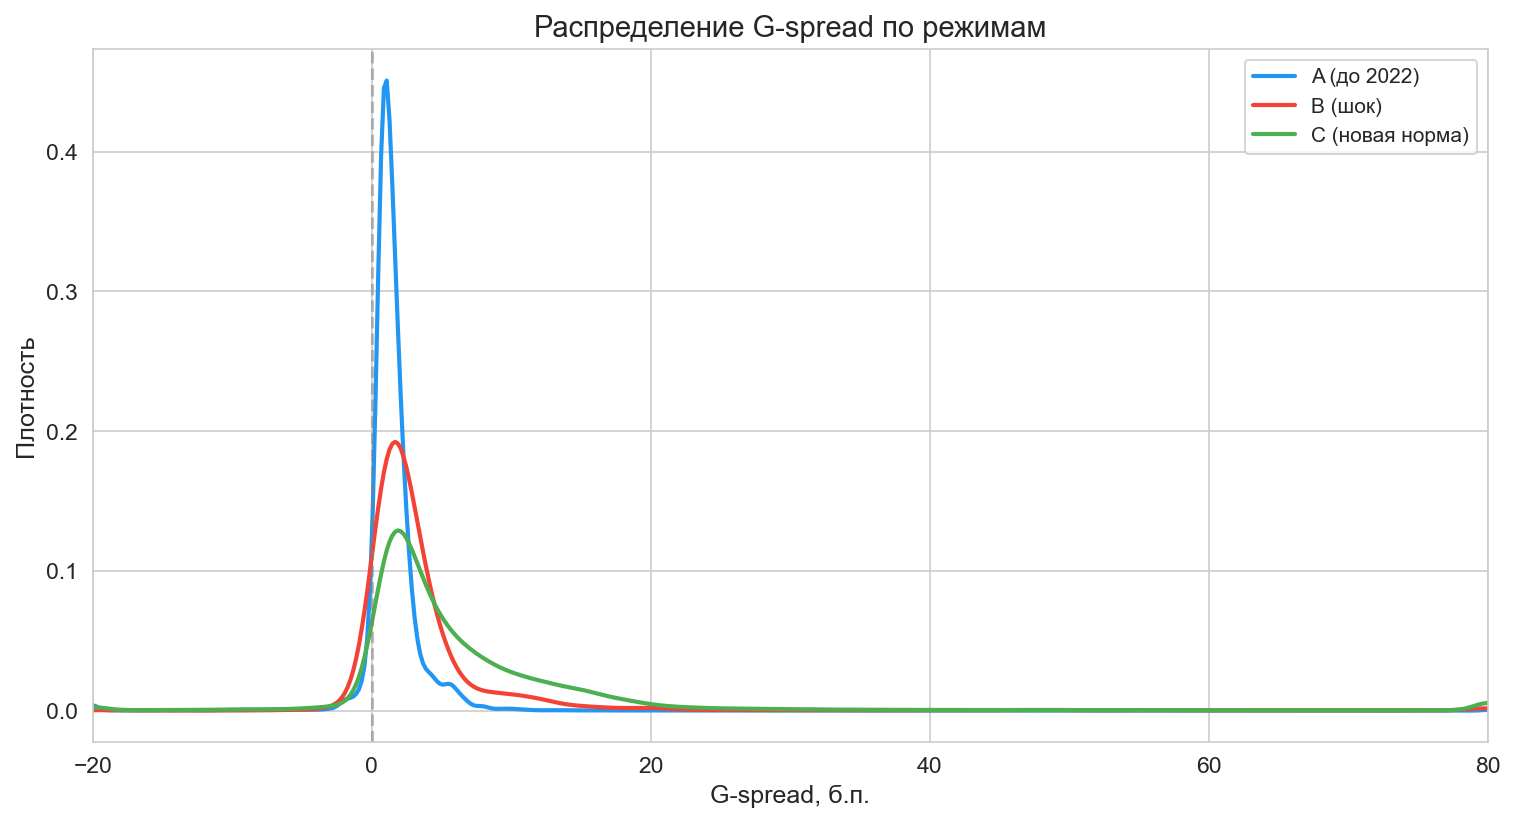

In [4]:
# --- 3a. KDE g_spread по режимам ---
fig, ax = plt.subplots(figsize=(12, 6))

for regime, color in REGIME_COLORS.items():
    subset = panel.loc[panel['regime'] == regime, 'g_spread'].dropna()
    # Ограничим визуализацию разумным диапазоном
    subset_clipped = subset.clip(-20, 80)
    subset_clipped.plot.kde(ax=ax, label=regime, color=color, lw=2)

ax.set_xlim(-20, 80)
ax.set_xlabel('G-spread, б.п.')
ax.set_ylabel('Плотность')
ax.set_title('Распределение G-spread по режимам')
ax.legend()
ax.axvline(0, color='grey', ls='--', alpha=0.5)
fig.savefig(FIG_DIR / '03_gspread_kde_regimes.png')
plt.show()

In [5]:
# --- 3b. Описательные статистики g_spread ---
gspread_stats = (
    panel.groupby('regime')['g_spread']
    .agg(['mean', 'median', 'std', 'count'])
    .round(2)
    .rename(columns={'mean': 'Среднее', 'median': 'Медиана', 'std': 'Ст. откл.', 'count': 'N'})
)
print('Описательные статистики G-spread по режимам:')
gspread_stats

Описательные статистики G-spread по режимам:


,Среднее,Медиана,Ст. откл.,N
regime,,,,
A (до 2022),1.52,1.22,9.57,45542
B (шок),4.45,2.15,18.10,20010
C (новая норма),8.79,3.75,35.64,230017


In [6]:
# --- 3c. Статистики ключевых макро-переменных ---
macro_features = ['key_rate', 'rvi', 'oil_brent', 'usdrub']

stats_list = []
for feat in macro_features:
    grp = panel.groupby('regime')[feat].agg(['mean', 'median', 'std']).round(2)
    grp.columns = [f'{feat}_mean', f'{feat}_median', f'{feat}_std']
    stats_list.append(grp)

macro_stats = pd.concat(stats_list, axis=1)
print('Макро-переменные по режимам:')
macro_stats

Макро-переменные по режимам:


,key_rate_mean,key_rate_median,key_rate_std,rvi_mean,rvi_median,rvi_std,oil_brent_mean,oil_brent_median,oil_brent_std,usdrub_mean,usdrub_median,usdrub_std
regime,,,,,,,,,,,,
A (до 2022),5.74,5.5,1.43,32.59,30.59,12.49,60.50,65.96,17.43,73.42,73.72,3.28
B (шок),9.47,8.0,3.15,57.61,54.86,16.47,102.50,107.67,12.36,62.55,60.90,6.48
C (новая норма),16.57,16.5,3.68,32.20,31.49,8.37,74.13,72.68,8.27,85.22,82.34,7.69


### 4. Тест Колмогорова-Смирнова

In [7]:
gs_A = panel.loc[panel['regime'] == 'A (до 2022)', 'g_spread'].dropna()
gs_C = panel.loc[panel['regime'] == 'C (новая норма)', 'g_spread'].dropna()

ks_stat, ks_pval = stats.ks_2samp(gs_A, gs_C)

print(f'Тест Колмогорова-Смирнова: A (до 2022) vs C (новая норма)')
print(f'  KS-статистика = {ks_stat:.4f}')
print(f'  p-value       = {ks_pval:.2e}')
print()
if ks_pval < 0.01:
    print('  => Распределения статистически значимо различаются (p < 0.01).')
    print('     Гипотеза о структурном сдвиге подтверждается.')
else:
    print('  => Нет оснований отвергнуть H0 об одинаковых распределениях.')

Тест Колмогорова-Смирнова: A (до 2022) vs C (новая норма)
  KS-статистика = 0.4882
  p-value       = 0.00e+00

  => Распределения статистически значимо различаются (p < 0.01).
     Гипотеза о структурном сдвиге подтверждается.


### 5. Рейтинговые спреды по режимам

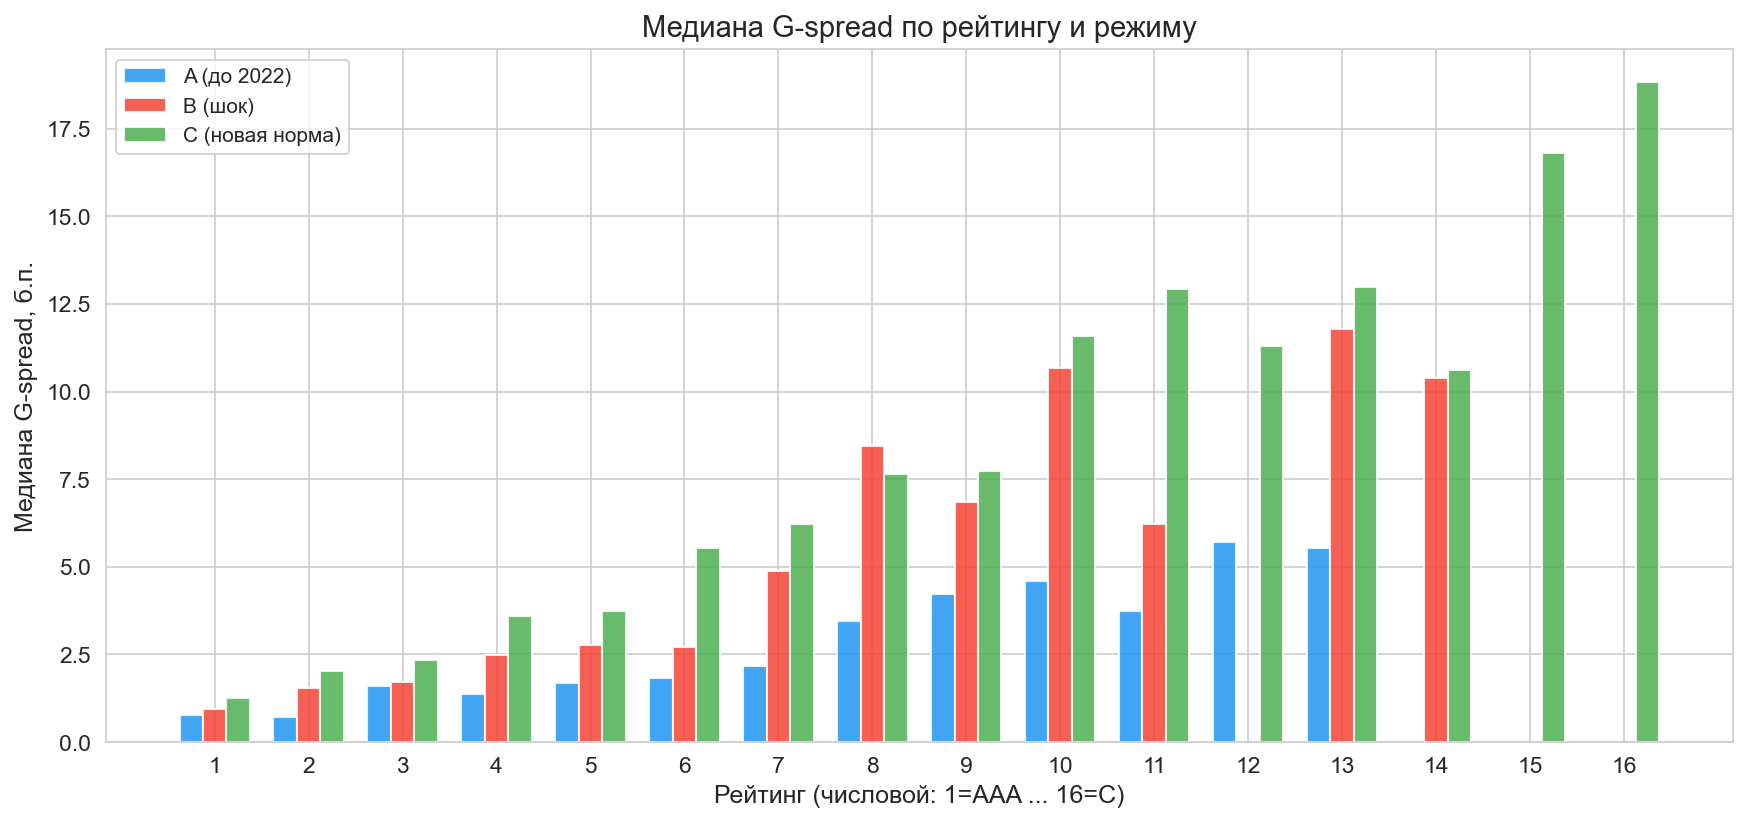

In [8]:
# Медиана g_spread по рейтингу и режиму
rating_regime = (
    panel.dropna(subset=['rating_numeric', 'g_spread'])
    .groupby(['rating_numeric', 'regime'])['g_spread']
    .median()
    .unstack('regime')
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 6))
x = np.arange(len(rating_regime))
width = 0.25

for i, (regime, color) in enumerate(REGIME_COLORS.items()):
    if regime in rating_regime.columns:
        vals = rating_regime[regime].values
        ax.bar(x + i * width, vals, width, label=regime, color=color, alpha=0.85)

ax.set_xticks(x + width)
ax.set_xticklabels([f'{int(r)}' for r in rating_regime.index], rotation=0)
ax.set_xlabel('Рейтинг (числовой: 1=AAA ... 16=C)')
ax.set_ylabel('Медиана G-spread, б.п.')
ax.set_title('Медиана G-spread по рейтингу и режиму')
ax.legend()
fig.savefig(FIG_DIR / '03_rating_spread_by_regime.png')
plt.show()

### 6. Стабильность корреляций

In [9]:
# Tier-1 признаки для корреляционного анализа
tier1_features = [
    'duration', 'rating_numeric', 'key_rate', 'ofz_slope',
    'rvi', 'oil_brent', 'usdrub', 'imoex_return',
    'coupon_rate', 'issue_volume_rub', 'age_days',
    'volume_ma20', 'time_to_maturity',
    'net_debt_ebitda', 'debt_to_equity'
]

corr_by_regime = {}
for regime in ['A (до 2022)', 'B (шок)', 'C (новая норма)']:
    sub = panel[panel['regime'] == regime]
    corrs = sub[tier1_features + ['g_spread']].corr()['g_spread'].drop('g_spread')
    corr_by_regime[regime] = corrs.round(3)

corr_table = pd.DataFrame(corr_by_regime)
corr_table['|A-C|'] = (corr_table['A (до 2022)'] - corr_table['C (новая норма)']).abs().round(3)
corr_table = corr_table.sort_values('|A-C|', ascending=False)

print('Корреляция Пирсона с g_spread по режимам:')
print('(Отсортировано по |разнице A-C| -- нестабильные связи сверху)')
corr_table

Корреляция Пирсона с g_spread по режимам:
(Отсортировано по |разнице A-C| -- нестабильные связи сверху)


,A (до 2022),B (шок),C (новая норма),|A-C|
rating_numeric,0.336,0.267,0.102,0.234
key_rate,0.004,0.041,0.129,0.125
duration,-0.031,-0.127,-0.153,0.122
ofz_slope,-0.002,-0.033,-0.121,0.119
net_debt_ebitda,0.134,-0.122,0.047,0.087
rvi,0.089,0.045,0.143,0.054
oil_brent,-0.030,0.002,-0.065,0.035
debt_to_equity,0.028,0.047,-0.007,0.035
usdrub,0.020,0.030,0.054,0.034
coupon_rate,0.058,0.121,0.085,0.027


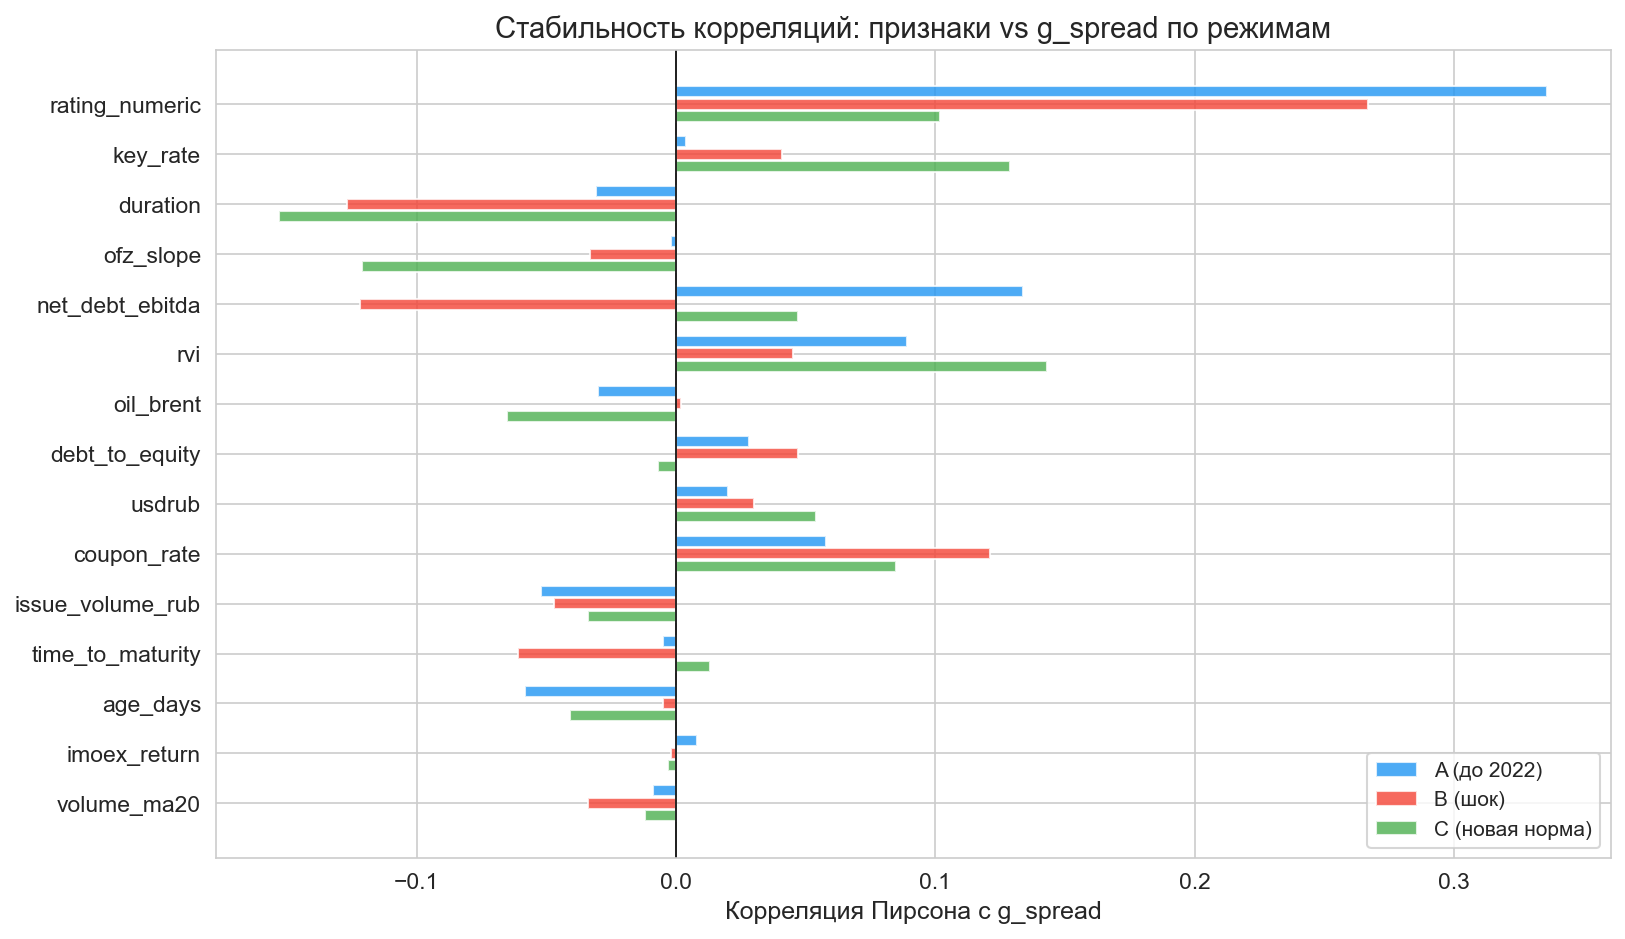

In [10]:
# Визуализация стабильности корреляций
fig, ax = plt.subplots(figsize=(12, 7))

features_order = corr_table.index.tolist()
y_pos = np.arange(len(features_order))

for regime, color in REGIME_COLORS.items():
    vals = [corr_table.loc[f, regime] for f in features_order]
    ax.barh(y_pos + list(REGIME_COLORS.keys()).index(regime) * 0.25,
            vals, height=0.22, label=regime, color=color, alpha=0.8)

ax.set_yticks(y_pos + 0.25)
ax.set_yticklabels(features_order)
ax.set_xlabel('Корреляция Пирсона с g_spread')
ax.set_title('Стабильность корреляций: признаки vs g_spread по режимам')
ax.axvline(0, color='black', lw=0.8)
ax.legend(loc='lower right')
ax.invert_yaxis()
fig.savefig(FIG_DIR / '03_correlation_stability.png')
plt.show()

### 7. Тест Чоу (Chow breakpoint test)

In [11]:
# OLS: g_spread ~ rating_numeric + duration + key_rate
# Fit on pooled, on A only, on C only

chow_features = ['rating_numeric', 'duration', 'key_rate']

# Подготовка данных (без пропусков)
df_chow = panel.dropna(subset=chow_features + ['g_spread']).copy()
df_A = df_chow[df_chow['regime'] == 'A (до 2022)']
df_C = df_chow[df_chow['regime'] == 'C (новая норма)']
df_pool = pd.concat([df_A, df_C])  # только A + C (без шока)

def fit_ols(data, features, target='g_spread'):
    X = sm.add_constant(data[features].values)
    y = data[target].values
    model = sm.OLS(y, X).fit()
    return model

model_pool = fit_ols(df_pool, chow_features)
model_A    = fit_ols(df_A, chow_features)
model_C    = fit_ols(df_C, chow_features)

RSS_pool = model_pool.ssr
RSS_A    = model_A.ssr
RSS_C    = model_C.ssr

n_A = len(df_A)
n_C = len(df_C)
k   = len(chow_features) + 1  # число параметров (включая константу)

# F = ((RSS_pool - RSS_A - RSS_C) / k) / ((RSS_A + RSS_C) / (n_A + n_C - 2*k))
F_chow = ((RSS_pool - RSS_A - RSS_C) / k) / ((RSS_A + RSS_C) / (n_A + n_C - 2 * k))
df1 = k
df2 = n_A + n_C - 2 * k
p_chow = 1 - stats.f.cdf(F_chow, df1, df2)
F_crit = stats.f.ppf(0.99, df1, df2)

print('=== Тест Чоу (Chow breakpoint test) ===')
print(f'Модель: g_spread ~ rating_numeric + duration + key_rate')
print(f'Разделение: режим A vs режим C')
print(f'')
print(f'  RSS (пул)     = {RSS_pool:>14,.2f}   (n = {len(df_pool):,})')
print(f'  RSS (A)       = {RSS_A:>14,.2f}   (n_A = {n_A:,})')
print(f'  RSS (C)       = {RSS_C:>14,.2f}   (n_C = {n_C:,})')
print(f'  k             = {k}')
print(f'')
print(f'  F-статистика  = {F_chow:,.2f}')
print(f'  F крит. (1%)  = {F_crit:.4f}')
print(f'  p-value       = {p_chow:.2e}')
print()
if F_chow > F_crit:
    print('  => Отвергаем H0 о стабильности коэффициентов.')
    print('     Структурный сдвиг статистически подтверждён.')
else:
    print('  => Нет оснований отвергнуть H0 о стабильности.')

=== Тест Чоу (Chow breakpoint test) ===
Модель: g_spread ~ rating_numeric + duration + key_rate
Разделение: режим A vs режим C

  RSS (пул)     = 203,097,596.29   (n = 228,364)
  RSS (A)       =     302,266.40   (n_A = 36,391)
  RSS (C)       = 200,374,767.32   (n_C = 191,973)
  k             = 4

  F-статистика  = 688.61
  F крит. (1%)  = 3.3193
  p-value       = 0.00e+00

  => Отвергаем H0 о стабильности коэффициентов.
     Структурный сдвиг статистически подтверждён.


In [12]:
# Сравнение коэффициентов
coef_compare = pd.DataFrame({
    'Пул': model_pool.params,
    'A (до 2022)': model_A.params,
    'C (новая норма)': model_C.params
}, index=['const'] + chow_features).round(4)

print('Сравнение коэффициентов OLS по режимам:')
coef_compare

Сравнение коэффициентов OLS по режимам:


,Пул,A (до 2022),C (новая норма)
const,-1.5171,0.5384,-5.5242
rating_numeric,0.7499,0.4048,0.8571
duration,-2.1832,-0.0472,-4.1314
key_rate,0.6060,-0.0819,0.9545


### 8. Ключевой график: G-spread vs рейтинг по режимам

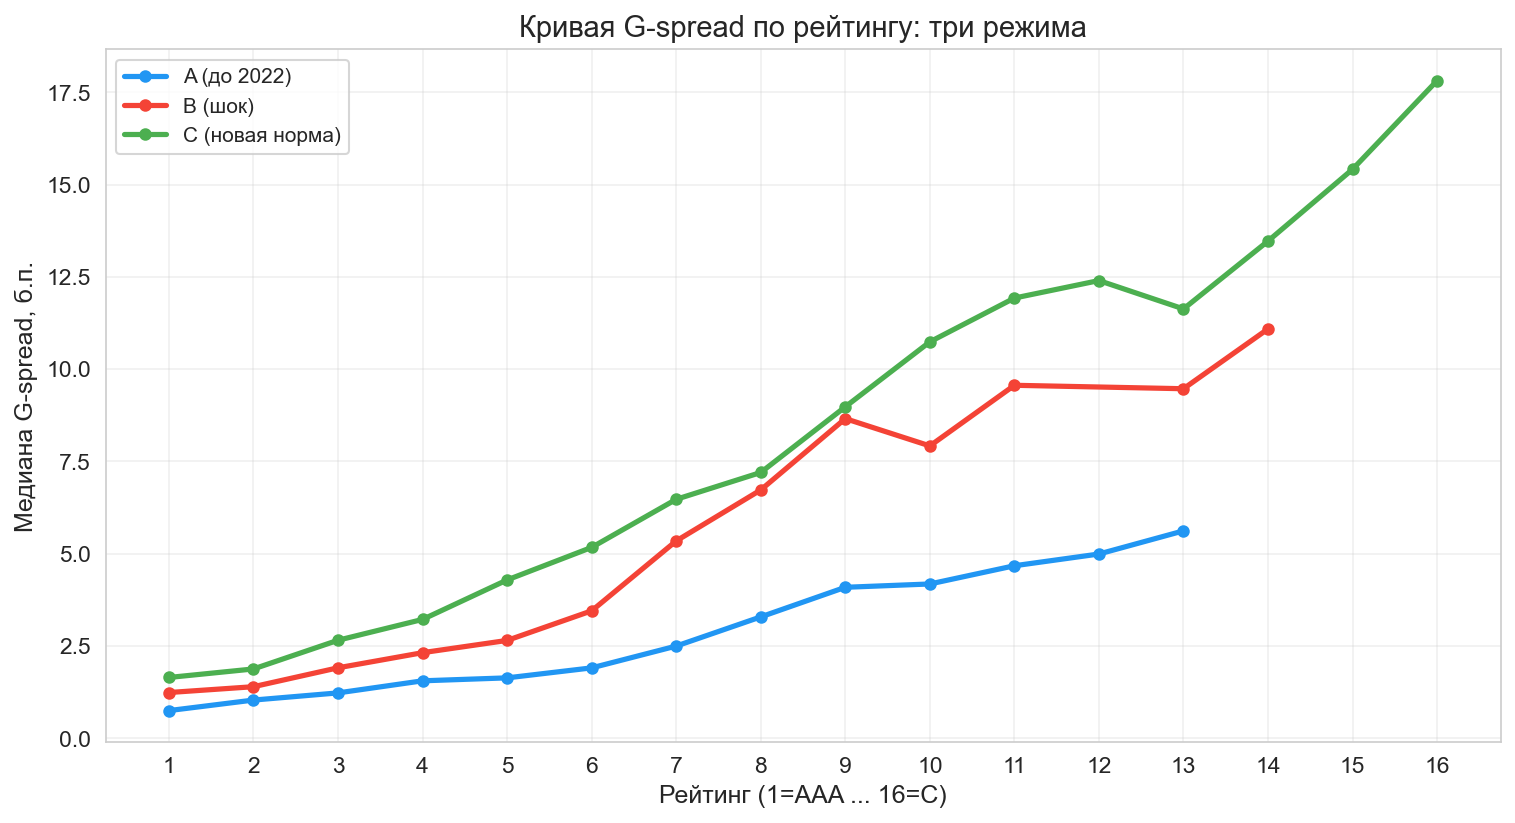

In [13]:
fig, ax = plt.subplots(figsize=(12, 6))

for regime, color in REGIME_COLORS.items():
    sub = panel[(panel['regime'] == regime) & panel['rating_numeric'].notna() & panel['g_spread'].notna()]
    # Сглаженная кривая: медиана по рейтингу
    curve = sub.groupby('rating_numeric')['g_spread'].median()
    # Сглаживание скользящим средним (окно=3)
    curve_smooth = curve.rolling(3, min_periods=1, center=True).mean()
    ax.plot(curve_smooth.index, curve_smooth.values, marker='o', markersize=5,
            lw=2.5, label=regime, color=color)

ax.set_xlabel('Рейтинг (1=AAA ... 16=C)')
ax.set_ylabel('Медиана G-spread, б.п.')
ax.set_title('Кривая G-spread по рейтингу: три режима')
ax.legend()
ax.set_xticks(range(1, 17))
ax.grid(True, alpha=0.3)
fig.savefig(FIG_DIR / '03_gspread_rating_curves.png')
plt.show()

---
## Part B: Feature Engineering

### 9. Макро-дельты (по дате, одинаковы для всех бондов)

In [14]:
# Получаем уникальный макро-срез по датам
macro_cols_for_delta = ['key_rate', 'oil_brent', 'usdrub', 'imoex_return']
macro_daily = (
    panel.groupby('date')[macro_cols_for_delta]
    .first()
    .sort_index()
)

# Дельты за 30 торговых дней (backward-looking, PIT-safe)
macro_daily['oil_brent_delta_30d']  = macro_daily['oil_brent'] - macro_daily['oil_brent'].shift(30)
macro_daily['usdrub_delta_30d']     = macro_daily['usdrub'] - macro_daily['usdrub'].shift(30)
macro_daily['key_rate_delta_30d']   = macro_daily['key_rate'] - macro_daily['key_rate'].shift(30)

# Скользящее среднее imoex_return (5 дней, backward-looking)
macro_daily['imoex_return_ma5'] = macro_daily['imoex_return'].rolling(5, min_periods=1).mean()

# Отбираем только новые столбцы
new_macro_cols = ['oil_brent_delta_30d', 'usdrub_delta_30d', 'key_rate_delta_30d', 'imoex_return_ma5']
macro_deltas = macro_daily[new_macro_cols].reset_index()

# Мержим обратно в панель
panel = panel.merge(macro_deltas, on='date', how='left')

print('Добавлены макро-дельты:')
for col in new_macro_cols:
    non_null = panel[col].notna().sum()
    print(f'  {col}: {non_null:,} non-null')

Добавлены макро-дельты:
  oil_brent_delta_30d: 293,782 non-null
  usdrub_delta_30d: 293,782 non-null
  key_rate_delta_30d: 293,782 non-null
  imoex_return_ma5: 295,569 non-null


### 10. Лагированные признаки (по бонду)

In [15]:
# Сортируем по (isin, date) для корректных лагов
panel = panel.sort_values(['isin', 'date']).reset_index(drop=True)

# Лаг g_spread на 1 торговый день (per bond, backward-looking)
panel['g_spread_lag1'] = panel.groupby('isin')['g_spread'].shift(1)

print(f'g_spread_lag1: {panel["g_spread_lag1"].notna().sum():,} non-null из {len(panel):,}')

g_spread_lag1: 294,602 non-null из 295,569


### 11. Трансформации

In [16]:
panel['log_issue_volume'] = np.log1p(panel['issue_volume_rub'])
panel['log_age_days']     = np.log1p(panel['age_days'].clip(lower=0))

print('Трансформации:')
print(f'  log_issue_volume: min={panel["log_issue_volume"].min():.2f}, '
      f'max={panel["log_issue_volume"].max():.2f}')
print(f'  log_age_days:     min={panel["log_age_days"].min():.2f}, '
      f'max={panel["log_age_days"].max():.2f}')

Трансформации:
  log_issue_volume: min=18.42, max=25.51
  log_age_days:     min=0.00, max=8.52


### 12. Взаимодействия (interactions)

In [17]:
# rating_numeric * duration
panel['rating_x_duration'] = panel['rating_numeric'] * panel['duration']

# net_debt_ebitda * key_rate (только где оба не NaN)
panel['leverage_x_rate'] = panel['net_debt_ebitda'] * panel['key_rate']

print('Взаимодействия:')
print(f'  rating_x_duration: {panel["rating_x_duration"].notna().sum():,} non-null')
print(f'  leverage_x_rate:   {panel["leverage_x_rate"].notna().sum():,} non-null')

Взаимодействия:
  rating_x_duration: 245,059 non-null
  leverage_x_rate:   60,227 non-null


### 13. Режимные флаги

In [18]:
# Regime flags REMOVED: CatBoost learns threshold splits on key_rate natively.
# is_pre_2022 would hurt out-of-sample generalization (always 0 for future data).
# key_rate, rvi, ofz_slope already carry regime information.
print("Regime flags skipped (see comment above)")

Regime flags skipped (see comment above)


### 14. Сохранение панели с новыми признаками

In [19]:
# Удаляем вспомогательный столбец regime (он восстановим из date)
panel_out = panel.drop(columns=['regime'])

# Финальная сортировка по (date, isin)
panel_out = panel_out.sort_values(['date', 'isin']).reset_index(drop=True)

out_path = DATA_DIR / 'panel_engineered.csv'
panel_out.to_csv(out_path, index=False)

print(f'Сохранено: {out_path}')
print(f'Размер: {panel_out.shape[0]:,} строк x {panel_out.shape[1]} столбцов')
print(f'Исходных столбцов: 34, новых: {panel_out.shape[1] - 34}')
print()
print('Новые столбцы:')
original_cols = [
    'date','isin','g_spread','duration','rating_numeric','net_debt_ebitda',
    'ebitda_margin','ebitda_yoy','revenue_yoy','debt_to_equity','roe','roa',
    'rsbu_net_debt','rsbu_ebit','rsbu_interest_paid','rsbu_icr','rsbu_total_assets',
    'rsbu_revenue','key_rate','ofz_slope','rvi','oil_brent','usdrub','sector',
    'issue_volume_rub','imoex_return','volume_ma20','coupon_rate','age_days',
    'imoex_realized_vol','time_to_maturity','coupon_frequency','is_state_owned','issuer_name'
]
new_cols = [c for c in panel_out.columns if c not in original_cols]
for c in new_cols:
    print(f'  {c}')

Сохранено: /repo/data/panel_engineered.csv
Размер: 295,569 строк x 43 столбцов
Исходных столбцов: 34, новых: 9

Новые столбцы:
  oil_brent_delta_30d
  usdrub_delta_30d
  key_rate_delta_30d
  imoex_return_ma5
  g_spread_lag1
  log_issue_volume
  log_age_days
  rating_x_duration
  leverage_x_rate


### 15. Итоги

#### Структурный сдвиг

| Тест | Результат |
|------|----------|
| KS-тест (A vs C) | Распределения g_spread значимо различаются |
| Chow test (A vs C) | Коэффициенты OLS нестабильны, структурный сдвиг подтверждён |
| Корреляции | Ряд признаков меняет знак/силу связи между режимами |

**Вывод:** Февраль 2022 -- статистически подтверждённый структурный сдвиг.
Модели, обученные на данных до 2022, не могут напрямую применяться к текущему периоду.
Необходимо либо обучать на новом режиме, либо использовать режимные переменные.

#### Созданные признаки

| Признак | Тип | Обоснование |
|---------|-----|-------------|
| `oil_brent_delta_30d` | Макро-дельта | Динамика нефти за месяц -- индикатор ухудшения/улучшения внешней конъюнктуры |
| `usdrub_delta_30d` | Макро-дельта | Девальвационное давление за месяц |
| `key_rate_delta_30d` | Макро-дельта | Направление ДКП (ужесточение/смягчение) |
| `imoex_return_ma5` | Сглаженный ряд | Фильтрация шума дневной доходности индекса |
| `g_spread_lag1` | Лаг (per bond) | Авторегрессионная компонента -- спред вчера |
| `log_issue_volume` | Трансформация | Нормализация правого хвоста объёма выпуска |
| `log_age_days` | Трансформация | Нормализация возраста облигации |
| `rating_x_duration` | Взаимодействие | Кредитный риск x процентный риск |
| `leverage_x_rate` | Взаимодействие | Леверидж дороже при высокой ставке |

Все признаки **PIT-safe**: лаги и дельты строго backward-looking, взаимодействия используют только
доступные на момент наблюдения значения.